In [1]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake
from firedrake import *
import numpy as np
import matplotlib.pyplot as plt

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


# Ex. 1 - Diffusion-reaction
Diffusion-reaction problem in the unit square domain $\Omega = {(0,1)}^2$, with Neumann boundary conditions:
\begin{equation*}
  \begin{cases}
    -\Delta u + 3 u = 2(y^2-1)e^{-x}, \qquad & \text{in }\Omega, \\
    \nabla u\cdot{\boldsymbol{n}} = -y^2 \qquad & \text{on }\Gamma_1 = \{x=0, 0\leq y\leq 1\},
    \\
    \nabla u\cdot{\boldsymbol{n}} = y^2 \qquad & \text{on }\Gamma_2 = \{x=1, 0\leq y\leq 1\},
    \\
    \nabla u\cdot{\boldsymbol{n}} = 0 \qquad & \text{on }\Gamma_3 = \{0\leq x\leq 1, y=0\},
    \\
    \nabla u\cdot{\boldsymbol{n}} = 1 \qquad & \text{on }\Gamma_4 = \{0\leq x\leq 1, y=1\}.\end{cases}
\end{equation*}

The numbers of $\Gamma_i$ correspond to the tags that *UnitSquareMesh* automatically assign to the four edges, used by *ds* (see below).

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


(np.float64(-0.05), np.float64(1.05), np.float64(-0.05), np.float64(1.05))

/home/aless/.local/share/mamba/envs/firedrake/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


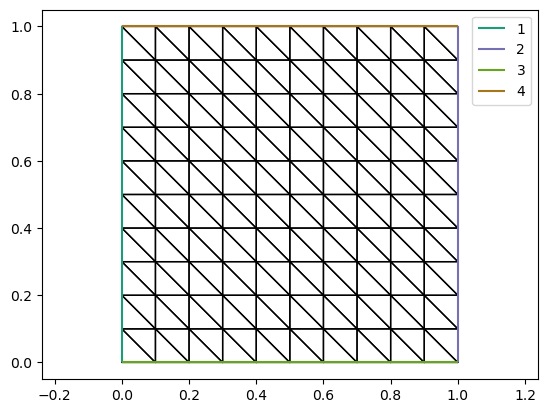

In [4]:
# Define and plot the mesh
N = 10
mesh = UnitSquareMesh(N, N)
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()
ax.axis('equal')

In [9]:
# Define function space and trial/test functions
V = FunctionSpace(mesh, "P", 1)
u = TrialFunction(V)
v = TestFunction(V)

# Define the source term and the bilinear and linear forms
x = SpatialCoordinate(mesh)
f = 2*((x[1]**2)-1)*exp(-x[0])
a = inner(grad(u), grad(v)) * dx + 3 * u * v * dx
L = f * v * dx - (x[1]**2) * v * ds(1) + (x[1]**2) * v * ds(2) + v * ds(4)

# Solve the problem
u_h = Function(V)
params = {'ksp_type': 'preonly', 'pc_type': 'lu'}
solve(a == L, u_h, solver_parameters=params)

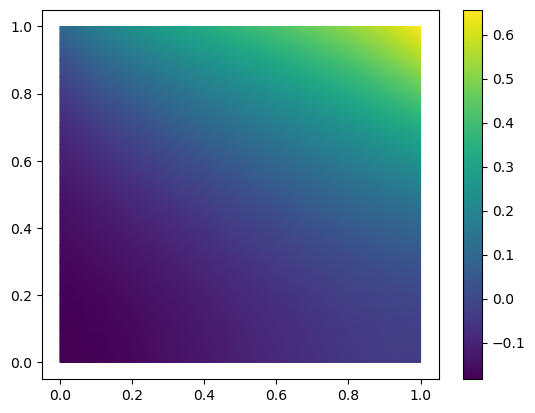

In [10]:
# Plot the numerical solution
fig, ax = plt.subplots()
q = tripcolor(u_h, axes=ax)
fig.colorbar(q)

In [7]:
# Algebraic formulation of the problem
A = assemble(a)
rhs = assemble(L)

solver = LinearSolver(A,
                      solver_parameters={'ksp_type': 'preonly',
                                         'pc_type': 'lu'})
u_h_alg = Function(V)
solver.solve(u_h_alg, rhs)

errH1 = sqrt( assemble( (u_h-u_h_alg) * (u_h-u_h_alg) * dx)
              + assemble( inner(grad(u_h-u_h_alg), grad(u_h-u_h_alg)) * dx ))
print('H1-difference =', errH1)

H1-difference = 1.2142493943856654e-15


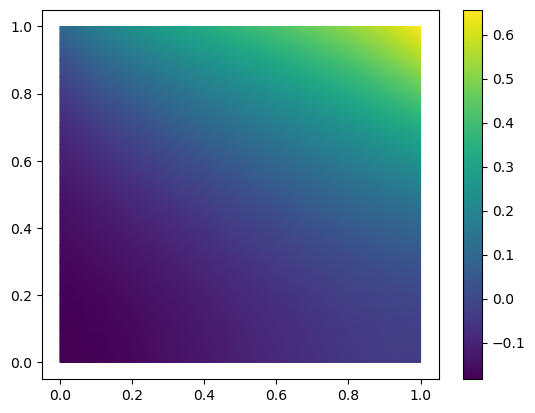

In [8]:
# Plot the numerical solution
fig, ax = plt.subplots()
q = tripcolor(u_h_alg, axes=ax)
fig.colorbar(q)

# Exercise 2
Laplace problem in the unit square domain $\Omega = {(0,1)}^2$, with mixed boundary conditions:
\begin{equation*}
  \begin{cases}
    -\Delta u = 0, \qquad & \text{in }\Omega, \\
    u  = y(1-y) \qquad & \text{on }\Gamma_1 = \{x=0, 0\leq y\leq 1\},
    \\
    u = 0 \qquad & \text{on }\Gamma_2 = \{x=1, 0\leq y\leq 1\},
    \\
    \nabla u\cdot{\boldsymbol{n}} = 1 \qquad & \text{on }\Gamma_3 = \{0\leq x\leq 1, y=0\},
    \\
    \nabla u\cdot{\boldsymbol{n}} = 0 \qquad & \text{on }\Gamma_4 = \{0\leq x\leq 1, y=1\}.\end{cases}
\end{equation*}


firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?


firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


(np.float64(-0.05), np.float64(1.05), np.float64(-0.05), np.float64(1.05))

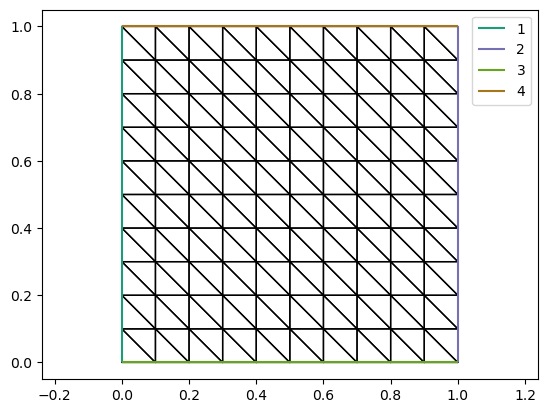

In [14]:
# Define and plot the mesh
N = 10
mesh = UnitSquareMesh(N, N)
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()
ax.axis('equal')

In [15]:
# Define function space and trial/test functions
V = FunctionSpace(mesh, "P", 1)
u = TrialFunction(V)
v = TestFunction(V)

# Define the source term and the bilinear and linear forms
x = SpatialCoordinate(mesh)
f = Constant(0.0)
a = inner(grad(u), grad(v)) * dx
L = Constant(1.0) * v * ds(3)

# Dirichlet BC
bc1 = DirichletBC(V, x[1] * (1 - x[1]), 1)
bc2 = DirichletBC(V, Constant(0.0), 2)
bcs = [bc1, bc2]

# Solve the problem
params = {'ksp_type': 'preonly', 'pc_type': 'lu'}
u_h = Function(V)
solve(a == L, u_h, bcs=bcs, solver_parameters=params)

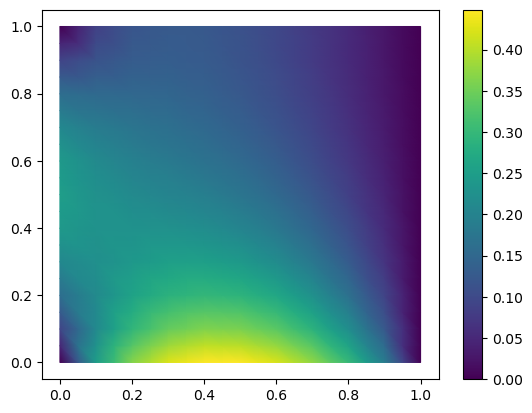

In [16]:
# Plot the numerical solution
fig, ax = plt.subplots()
q = tripcolor(u_h, axes=ax)
fig.colorbar(q)

In [17]:
# Algebraic formulation of the problem
A = assemble(a, bcs=bcs)
rhs = assemble(L, bcs=bcs)

solver = LinearSolver(A,
                      solver_parameters={'ksp_type': 'preonly',
                                         'pc_type': 'lu'})
u_h_alg = Function(V)
solver.solve(u_h_alg, rhs)

errH1 = sqrt( assemble( (u_h-u_h_alg) * (u_h-u_h_alg) * dx)
              + assemble( inner(grad(u_h-u_h_alg), grad(u_h-u_h_alg)) * dx ))
print('H1-difference =', errH1)

H1-difference = 5.844869994759321e-18


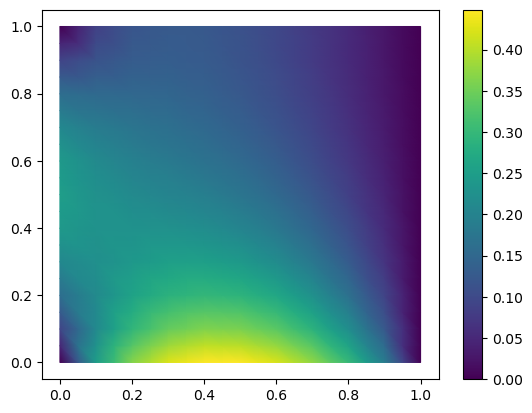

In [18]:
# Plot the numerical solution
fig, ax = plt.subplots()
q = tripcolor(u_h_alg, axes=ax)
fig.colorbar(q)